# 03 — DeiT-small Fine-Tuning: Document Classification
**Group 1 – Invoices | Step 3**

| # | Model | Parametri | Strategia |
|---|-------|-----------|-----------|
| 1 | **DeiT-small-distilled** | ~22M | Freeze backbone → train head → unfreeze top layers |

**Strategy:** Two-phase fine-tuning on RVL-CDIP (16 classes).
- **Fase 1** – solo classification head (3 epoch, LR alta)
- **Fase 2** – ultimi 4 transformer blocks + head (5 epoch, LR bassa)

> **Checkpoint system**: best model salvato automaticamente per validation loss.

## 0 — Environment setup

In [1]:
import os

In [2]:
def _is_kaggle():
    return os.path.exists('/kaggle/working')
def _is_colab():
    try:
        import google.colab
        return not _is_kaggle()
    except ImportError:
        return False
PLATFORM = 'kaggle' if _is_kaggle() else ('colab' if _is_colab() else 'local')
print(PLATFORM)

colab


In [3]:
if PLATFORM == 'colab':
    USE_DRIVE = True
    if USE_DRIVE:
        from google.colab import drive
        drive.mount('/content/drive')
        OUTPUT_DIR = '/content/drive/MyDrive/NLP_Invoices/outputs'
    else:
        OUTPUT_DIR = '/content/outputs'
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    from huggingface_hub import get_token
    HF_TOKEN = get_token()
    if not HF_TOKEN:
        try:
            from google.colab import userdata
            HF_TOKEN = userdata.get('HF_TOKEN')
        except Exception: pass
    if not HF_TOKEN: raise ValueError('HF_TOKEN non trovato.')
    from huggingface_hub import login
    login(token=HF_TOKEN)
    print('✅ Colab ready')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Colab ready


In [4]:
if PLATFORM == 'kaggle':
    OUTPUT_DIR = '/kaggle/working/outputs'
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    HF_TOKEN = None
    try:
        from kaggle_secrets import UserSecretsClient
        HF_TOKEN = UserSecretsClient().get_secret('HF_TOKEN')
        print('HF_TOKEN letto dai Kaggle Secrets')
    except Exception as _e:
        print(f'Kaggle Secrets non disponibili: {_e}')
    KAGGLE_TOKEN_FILE = '/kaggle/input/MY-HF-TOKEN-DATASET/hf_token.txt'
    if not HF_TOKEN and os.path.isfile(KAGGLE_TOKEN_FILE):
        with open(KAGGLE_TOKEN_FILE) as _f:
            HF_TOKEN = _f.read().strip()
    if not HF_TOKEN: raise ValueError('HF_TOKEN non trovato.')
    from huggingface_hub import login
    login(token=HF_TOKEN)
    print(f'✅ Kaggle ready. Output → {OUTPUT_DIR}')

In [5]:
if PLATFORM == 'local':
    OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    from huggingface_hub import get_token, login
    HF_TOKEN = get_token() or os.environ.get('HF_TOKEN', '')
    if not HF_TOKEN: raise ValueError('HF_TOKEN non trovato.')
    login(token=HF_TOKEN)
    print(f'✅ Local ready. Output → {OUTPUT_DIR}')

## 1 — Install dependencies

In [6]:
import sys
!{sys.executable} -m pip install -q datasets transformers timm torchvision tqdm
!{sys.executable} -m pip install -q accelerate
print('✅ Dependencies installed')

✅ Dependencies installed


## 1 — Imports & configuration

In [7]:
import random, gc, pickle, time
from collections import defaultdict
from io import BytesIO
from pathlib import Path

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from transformers import AutoImageProcessor, AutoModelForImageClassification
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
from tqdm.notebook import tqdm

# ── Iperparametri ──────────────────────────────────────────────────────────────
MODEL_ID       = "facebook/deit-small-distilled-patch16-224"
# N_PER_CLASS removed: test set uses the full official split
N_TRAIN_CLASS  = 2000         # campioni di train per classe (dal train split)
N_VAL_CLASS    = 100          # campioni di val per classe (dal val split)
INVOICE_LABEL  = 6
RANDOM_SEED    = 42
NUM_WORKERS    = 2
BATCH_SIZE     = 32
IMG_SIZE       = 224

# Fase 1: solo head
LR_HEAD        = 3e-4
EPOCHS_HEAD    = 3

# Fase 2: top blocks + head
LR_FULL        = 5e-5
EPOCHS_FULL    = 5
UNFREEZE_BLOCKS = 4           # ultimi N transformer blocks da sbloccare

os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

LABEL_NAMES = {
    0:"advertisement", 1:"budget", 2:"email", 3:"file folder", 4:"form",
    5:"handwritten", 6:"invoice", 7:"letter", 8:"memo", 9:"news article",
    10:"presentation", 11:"questionnaire", 12:"resume", 13:"scientific publication",
    14:"scientific report", 15:"specification"
}
ALL_LABELS  = list(LABEL_NAMES.keys())
CLASS_NAMES = [LABEL_NAMES[i] for i in ALL_LABELS]
NUM_CLASSES = len(CLASS_NAMES)

BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "deit_small_best.pt")
print("Config ready.")

Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 102.0 GB
Config ready.


## 2 — Helper functions

In [8]:
import warnings
from PIL import UnidentifiedImageError

def to_pil(image_field):
    if isinstance(image_field, Image.Image):
        return image_field.convert("RGB")
    elif isinstance(image_field, dict):
        return Image.open(BytesIO(image_field["bytes"])).convert("RGB")
    else:
        return Image.fromarray(image_field).convert("RGB")


class DocDataset(Dataset):
    """Dataset con augmentation configurabile per train/val/test.
    Gestisce immagini corrotte restituendo un tensore nero come fallback.
    """
    def __init__(self, examples, processor, augment=False):
        self.examples  = examples
        self.processor = processor
        self.augment   = augment

        if augment:
            from torchvision import transforms
            self.aug = transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.3),
                transforms.RandomRotation(degrees=5),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
                transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
            ])
        else:
            self.aug = None

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, i):
        ex = self.examples[i]
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")  # sopprimi EXIF warnings
                img = to_pil(ex["image"])
        except (UnidentifiedImageError, Exception):
            # Fallback: black image — not ideal but prevents DataLoader crashes
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), color=0)
        if self.aug:
            img = self.aug(img)
        inputs = self.processor(images=img, return_tensors="pt")
        pixel_values = inputs["pixel_values"].squeeze(0)
        return pixel_values, int(ex["label"])


def make_loader(examples, processor, augment=False, batch_size=BATCH_SIZE, shuffle=False):
    ds = DocDataset(examples, processor, augment=augment)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
    )


def free_memory(*objs):
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    print("Memory freed.")


print("Helpers ready.")

Helpers ready.


## 3a — Cache dataset to disk
If a cache already exists it is loaded directly; otherwise the dataset is streamed and saved. This avoids re-downloading on every run.
- Prima esecuzione: ~30-45 min (streaming HuggingFace)
- Esecuzioni successive: ~1-2 min (lettura da disco)

In [11]:
import pickle, warnings
from pathlib import Path

CACHE_DIR  = Path(OUTPUT_DIR) / "dataset_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CACHE_FILE = CACHE_DIR / f"rvl_cdip_train{N_TRAIN_CLASS}_val{N_VAL_CLASS}_testFULL_seed{RANDOM_SEED}.pkl"


def download_and_cache():
    """Scarica il dataset via streaming e salva su disco.
    - Train/Val: campiona N esempi per classe (bilanciato)
    - Test: scarica TUTTO lo split ufficiale (garantisce tutte le 16 classi)
    """
    print("📥 Cache non trovata — scarico il dataset via streaming...")
    print("   (questa operazione richiede ~30-45 min alla prima esecuzione)\n")

    data = {}
    # n=None for test means: download the full split without a cap
    for split_name, hf_split, n, seed in [
        ("train", "train",      N_TRAIN_CLASS, RANDOM_SEED),
        ("val",   "val", N_VAL_CLASS,   RANDOM_SEED + 1),
        ("test",  "test",       None,          RANDOM_SEED + 2),
    ]:
        print(f"Caricamento {split_name} split...")
        stream = load_dataset("chainyo/rvl-cdip", split=hf_split, streaming=True,
                              cache_dir=CACHE_DIR,
                  ).shuffle(seed=seed, buffer_size=20_000)
        bucket  = defaultdict(list)
        done    = set()
        skipped = 0
        it      = iter(stream)

        while True:
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    ex = next(it)
            except StopIteration:
                break
            except Exception:
                skipped += 1
                continue

            label = int(ex["label"])

            # For train/val: skip classes that are already complete
            if n is not None and label in done:
                continue

            # Serialize image bytes immediately to save RAM
            img = to_pil(ex["image"])
            from io import BytesIO
            buf = BytesIO()
            img.save(buf, format="PNG")
            bucket[label].append({"image_bytes": buf.getvalue(), "label": label})

            # For train/val: mark class as done when it reaches n samples
            if n is not None and len(bucket[label]) == n:
                done.add(label)
                print(f"  ✓ {split_name}/{LABEL_NAMES[label]}")
                if len(done) == len(ALL_LABELS):
                    break  # tutte le classi complete, esci subito

        # For test: print per-class count
        if n is None:
            for lbl in ALL_LABELS:
                cnt = len(bucket[lbl])
                print(f"  ✓ {split_name}/{LABEL_NAMES[lbl]}: {cnt} esempi")
            missing = [LABEL_NAMES[l] for l in ALL_LABELS if len(bucket[l]) == 0]
            if missing:
                print(f"  ⚠️  Classi ancora mancanti: {missing}")

        if skipped:
            print(f"  ⚠️  {skipped} immagini corrotte skippate in \'{split_name}\'")
        if n is not None and len(done) < len(ALL_LABELS):
            missing = [LABEL_NAMES[l] for l in ALL_LABELS if l not in done]
            print(f"  ⚠️  Classi incomplete: {missing}")

        examples = [ex for exs in bucket.values() for ex in exs]
        random.seed(seed)
        random.shuffle(examples)
        data[split_name] = examples
        print(f"✅ {split_name.capitalize()}: {len(examples)} esempi\n")

    print(f"💾 Salvo cache → {CACHE_FILE}")
    with open(CACHE_FILE, "wb") as f:
        pickle.dump(data, f, protocol=4)
    print("✅ Cache salvata.")
    return data


def load_from_cache(cache_file):
    """Carica il dataset dalla cache su disco."""
    print(f"✅ Cache trovata — carico da disco: {cache_file.name}")
    with open(cache_file, "rb") as f:
        data = pickle.load(f)
    return data


# ── DocDataset: legge da bytes (cache) o da HF examples (streaming) ──────────
class DocDataset(Dataset):
    """Dataset che legge immagini da bytes (cache) o da HF examples (streaming).
    Gestisce entrambi i formati in modo trasparente.
    """
    def __init__(self, examples, processor, augment=False):
        self.examples  = examples
        self.processor = processor
        self.augment   = augment

        if augment:
            from torchvision import transforms
            self.aug = transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.3),
                transforms.RandomRotation(degrees=5),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
                transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
            ])
        else:
            self.aug = None

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, i):
        ex = self.examples[i]
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                if "image_bytes" in ex:
                    img = Image.open(BytesIO(ex["image_bytes"])).convert("RGB")
                else:
                    img = to_pil(ex["image"])
        except Exception:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), color=0)
        if self.aug:
            img = self.aug(img)
        inputs = self.processor(images=img, return_tensors="pt")
        return inputs["pixel_values"].squeeze(0), int(ex["label"])


# ── Load from cache or download ──────────────────────────────────────────────
if CACHE_FILE.exists():
    dataset = load_from_cache(CACHE_FILE)
else:
    dataset = download_and_cache()

train_examples = dataset["train"]
val_examples   = dataset["val"]
test_examples  = dataset["test"]
true_labels    = [ex["label"] for ex in test_examples]

# Class distribution in the test set
from collections import Counter
test_dist = Counter(ex["label"] for ex in test_examples)
print(f"Train : {len(train_examples)} esempi")
print(f"Val   : {len(val_examples)} esempi")
print(f"Test  : {len(test_examples)} esempi")
print(f"\nDistribuzione test per classe:")
for lbl in ALL_LABELS:
    print(f"  {LABEL_NAMES[lbl]:<30} {test_dist.get(lbl, 0):>4} esempi")


📥 Cache non trovata — scarico il dataset via streaming...
   (questa operazione richiede ~30-45 min alla prima esecuzione)

Caricamento train split...


Resolving data files:   0%|          | 0/119 [00:00<?, ?it/s]

  ✓ train/advertisement
  ✓ train/resume
  ✓ train/news article
  ✓ train/file folder
  ✓ train/invoice
  ✓ train/letter
  ✓ train/form
  ✓ train/handwritten
  ✓ train/email
  ✓ train/specification
  ✓ train/questionnaire
  ✓ train/scientific publication
  ✓ train/presentation
  ✓ train/scientific report
  ✓ train/budget
  ✓ train/memo
✅ Train: 32000 esempi

Caricamento val split...


Resolving data files:   0%|          | 0/119 [00:00<?, ?it/s]

  ✓ val/scientific report
  ✓ val/scientific publication
  ✓ val/email
  ✓ val/budget
  ✓ val/memo
  ✓ val/questionnaire
  ✓ val/specification
  ✓ val/news article
  ✓ val/letter
  ✓ val/presentation
  ✓ val/handwritten
  ✓ val/resume
  ✓ val/file folder
  ✓ val/invoice
  ✓ val/form
  ✓ val/advertisement
✅ Val: 1600 esempi

Caricamento test split...


Resolving data files:   0%|          | 0/119 [00:00<?, ?it/s]

  ✓ test/advertisement: 194 esempi
  ✓ test/budget: 15 esempi
  ✓ test/email: 0 esempi
  ✓ test/file folder: 172 esempi
  ✓ test/form: 198 esempi
  ✓ test/handwritten: 42 esempi
  ✓ test/invoice: 0 esempi
  ✓ test/letter: 0 esempi
  ✓ test/memo: 99 esempi
  ✓ test/news article: 198 esempi
  ✓ test/presentation: 195 esempi
  ✓ test/questionnaire: 146 esempi
  ✓ test/resume: 26 esempi
  ✓ test/scientific publication: 148 esempi
  ✓ test/scientific report: 149 esempi
  ✓ test/specification: 0 esempi
  ⚠️  Classi ancora mancanti: ['email', 'invoice', 'letter', 'specification']
  ⚠️  1 immagini corrotte skippate in 'test'
✅ Test: 1582 esempi

💾 Salvo cache → /content/drive/MyDrive/NLP_Invoices/outputs/dataset_cache/rvl_cdip_train2000_val100_testFULL_seed42.pkl
✅ Cache salvata.
Train : 32000 esempi
Val   : 1600 esempi
Test  : 1582 esempi

Distribuzione test per classe:
  advertisement                   194 esempi
  budget                           15 esempi
  email                           

In [17]:
from collections import Counter, defaultdict
from io import BytesIO

MISSING_LABELS = [l for l in ALL_LABELS
                  if Counter(ex["label"] for ex in test_examples).get(l, 0) == 0]
print(f"Classi mancanti: {[LABEL_NAMES[l] for l in MISSING_LABELS]}")

# Map class name → label index used in this project
NAME_TO_LABEL = {v: k for k, v in LABEL_NAMES.items()}  # es. "invoice" → 6

fill_stream = load_dataset("vaclavpechtor/rvl_cdip-small-200", split="train", streaming=True)

# Detect label mapping for this dataset
sample = next(iter(fill_stream))
ext_label_names = fill_stream.features["label"].names  # ["letter", "form", ...]
EXT_TO_MINE = {i: NAME_TO_LABEL.get(name) for i, name in enumerate(ext_label_names)}

fill_bucket = defaultdict(list)
fill_done   = set()

for ex in fill_stream:
    ext_label = int(ex["label"])
    my_label  = EXT_TO_MINE.get(ext_label)
    if my_label is None or my_label not in MISSING_LABELS or my_label in fill_done:
        continue
    img = to_pil(ex["image"])
    buf = BytesIO()
    img.save(buf, format="PNG")
    fill_bucket[my_label].append({"image_bytes": buf.getvalue(), "label": my_label})
    if len(fill_bucket[my_label]) >= 100:
        fill_done.add(my_label)
        print(f"  ✓ {LABEL_NAMES[my_label]}: {len(fill_bucket[my_label])} esempi")
    if fill_done == set(MISSING_LABELS):
        break

for exs in fill_bucket.values():
    test_examples.extend(exs)
true_labels = [ex["label"] for ex in test_examples]
print(f"\n✅ Test: {len(test_examples)} esempi totali")
print(f"   Invoice: {sum(1 for ex in test_examples if ex['label'] == INVOICE_LABEL)}")

Classi mancanti: ['email', 'invoice', 'letter', 'specification']


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


Resolving data files:   0%|          | 0/2560 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/640 [00:00<?, ?it/s]

  ✓ email: 100 esempi
  ✓ invoice: 100 esempi
  ✓ letter: 100 esempi
  ✓ specification: 100 esempi

✅ Test: 1982 esempi totali
   Invoice: 100


## 4 — Load DeiT-small & setup
DeiT-small-distilled ha una doppia testa (`classifier` + `cls_classifier`).
Sostituiamo entrambe con un linear layer a 16 uscite.

In [18]:
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model     = AutoModelForImageClassification.from_pretrained(
    MODEL_ID,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True,   # necessario: sostituisce la testa originale
    id2label={i: n for i, n in LABEL_NAMES.items()},
    label2id={n: i for i, n in LABEL_NAMES.items()},
)
model = model.to(DEVICE)

# DeiT-distilled ha due classifier: 'classifier' e 'cls_classifier'
# ignore_mismatched_sizes already re-initialises them — verify
print(f"cls_classifier output: {model.cls_classifier.out_features}")
print(f"distillation_classifier output: {model.distillation_classifier.out_features}")

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParametri totali   : {total_params/1e6:.1f}M")
print(f"Parametri trainable: {trainable_params/1e6:.1f}M")
print("Model ready.")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `DeiTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/89.8M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

DeiTForImageClassificationWithTeacher LOAD REPORT from: facebook/deit-small-distilled-patch16-224
Key                            | Status   |                                                                                         
-------------------------------+----------+-----------------------------------------------------------------------------------------
cls_classifier.bias            | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([16])          
distillation_classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([16, 384])
cls_classifier.weight          | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([16, 384])
distillation_classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([16])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


cls_classifier output: 16
distillation_classifier output: 16

Parametri totali   : 21.7M
Parametri trainable: 21.7M
Model ready.


## 5 — Training utilities

In [19]:
def freeze_backbone(model):
    """Freeze all parameters except the classification heads."""
    for name, param in model.named_parameters():
        if "classifier" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Fase 1 — trainable: {n/1e6:.2f}M params (solo head)")


def unfreeze_top_blocks(model, n_blocks=UNFREEZE_BLOCKS):
    """Sblocca gli ultimi n_blocks transformer blocks + le teste."""
    # DeiT transformer blocks are in model.deit.encoder.layer
    blocks = model.deit.encoder.layer
    total  = len(blocks)
    for i, block in enumerate(blocks):
        if i >= total - n_blocks:
            for param in block.parameters():
                param.requires_grad = True
    # Also unfreeze the final layer norm
    for param in model.deit.layernorm.parameters():
        param.requires_grad = True
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Fase 2 — trainable: {n/1e6:.2f}M params (top {n_blocks} blocks + head)")


def run_epoch(model, loader, criterion, optimizer=None, phase="train"):
    """Esegue una epoch di train o eval. Restituisce (loss, accuracy)."""
    is_train = phase == "train"
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for pixel_values, labels in loader:
            pixel_values = pixel_values.to(DEVICE)
            labels       = labels.to(DEVICE)
            outputs      = model(pixel_values=pixel_values)
            # DeiT-distilled restituisce logits come media delle due teste
            logits = outputs.logits
            loss   = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            preds    = logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            total_loss += loss.item() * labels.size(0)

    return total_loss / total, correct / total


def train_phase(model, train_loader, val_loader, criterion,
                optimizer, scheduler, epochs, phase_name, best_val_loss):
    """Loop di training per una fase. Salva il best model."""
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, "train")
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion, None,      "val")
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        elapsed = time.time() - t0
        print(f"  [{phase_name}] Epoch {epoch:02d}/{epochs}"
              f"  loss {tr_loss:.4f}/{vl_loss:.4f}"
              f"  acc {tr_acc:.3f}/{vl_acc:.3f}"
              f"  ({elapsed:.0f}s)")

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f"    💾 Best model salvato (val_loss={vl_loss:.4f})")

    return history, best_val_loss


print("Training utilities ready.")

Training utilities ready.


## 6 — Phase 1: train classification head only
The backbone is fully frozen. Only the `classifier` and `cls_classifier` layers are updated.
Converge in 2-3 epoch e stabilizza un buon punto di partenza per la fase 2.

In [20]:
freeze_backbone(model)

train_loader = make_loader(train_examples, processor, augment=True,  shuffle=True)
val_loader   = make_loader(val_examples,   processor, augment=False, shuffle=False)

# ── Class weights: penalizza di più gli errori sulle invoice ──────────────────
class_weights = torch.ones(NUM_CLASSES, device=DEVICE)
class_weights[INVOICE_LABEL] = 8.0   # aumenta il costo degli errori su invoice
                                      # prova valori tra 5.0 e 10.0 se F1 è bassa
criterion  = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
print(f"  Invoice class weight: {class_weights[INVOICE_LABEL].item():.1f}x")
optimizer1 = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                   lr=LR_HEAD, weight_decay=1e-4)
scheduler1 = CosineAnnealingLR(optimizer1, T_max=EPOCHS_HEAD, eta_min=1e-6)

print(f"\nFase 1 — {EPOCHS_HEAD} epoch, LR={LR_HEAD}")
best_val_loss = float("inf")
history1, best_val_loss = train_phase(
    model, train_loader, val_loader, criterion,
    optimizer1, scheduler1, EPOCHS_HEAD, "HEAD", best_val_loss
)
print("\n✅ Fase 1 completata.")

  Fase 1 — trainable: 0.01M params (solo head)
  Invoice class weight: 8.0x

Fase 1 — 3 epoch, LR=0.0003
  [HEAD] Epoch 01/3  loss 1.6583/1.5265  acc 0.429/0.502  (316s)
    💾 Best model salvato (val_loss=1.5265)
  [HEAD] Epoch 02/3  loss 1.4911/1.4675  acc 0.531/0.536  (316s)
    💾 Best model salvato (val_loss=1.4675)
  [HEAD] Epoch 03/3  loss 1.4552/1.4554  acc 0.549/0.542  (316s)
    💾 Best model salvato (val_loss=1.4554)

✅ Fase 1 completata.


## 7 — Fase 2: fine-tuning top blocks + head
Sbloccati gli ultimi 4 transformer blocks. Learning rate molto più bassa per evitare
catastrophic forgetting delle feature pre-trainati.

In [21]:
unfreeze_top_blocks(model, UNFREEZE_BLOCKS)

optimizer2 = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                   lr=LR_FULL, weight_decay=1e-4)
scheduler2 = CosineAnnealingLR(optimizer2, T_max=EPOCHS_FULL, eta_min=1e-7)

print(f"\nFase 2 — {EPOCHS_FULL} epoch, LR={LR_FULL}")
history2, best_val_loss = train_phase(
    model, train_loader, val_loader, criterion,
    optimizer2, scheduler2, EPOCHS_FULL, "FULL", best_val_loss
)
print("\n✅ Fase 2 completata.")
print(f"Best val loss: {best_val_loss:.4f}")

  Fase 2 — trainable: 7.11M params (top 4 blocks + head)

Fase 2 — 5 epoch, LR=5e-05
  [FULL] Epoch 01/5  loss 1.3315/1.2312  acc 0.626/0.678  (315s)
    💾 Best model salvato (val_loss=1.2312)
  [FULL] Epoch 02/5  loss 1.1566/1.1498  acc 0.709/0.730  (315s)
    💾 Best model salvato (val_loss=1.1498)
  [FULL] Epoch 03/5  loss 1.0584/1.0967  acc 0.757/0.748  (315s)
    💾 Best model salvato (val_loss=1.0967)
  [FULL] Epoch 04/5  loss 0.9905/1.0732  acc 0.785/0.756  (315s)
    💾 Best model salvato (val_loss=1.0732)
  [FULL] Epoch 05/5  loss 0.9514/1.0583  acc 0.803/0.762  (315s)
    💾 Best model salvato (val_loss=1.0583)

✅ Fase 2 completata.
Best val loss: 1.0583


## 8 — Learning curves

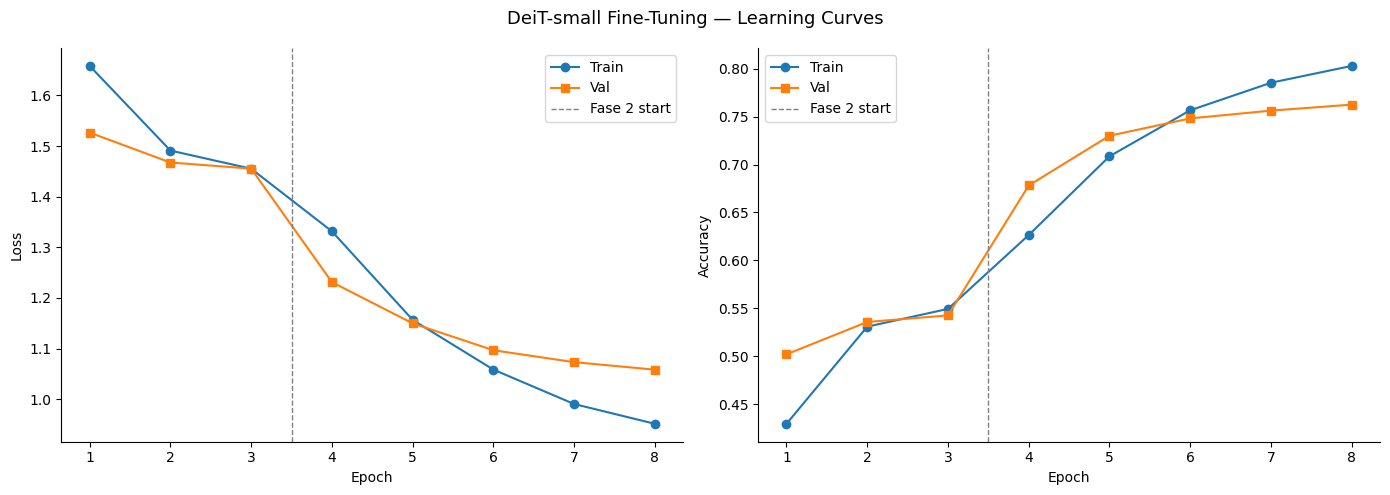

Saved → /content/drive/MyDrive/NLP_Invoices/outputs/03_deit_learning_curves.png


In [22]:
# Merge training histories from both phases
all_train_loss = history1["train_loss"] + history2["train_loss"]
all_val_loss   = history1["val_loss"]   + history2["val_loss"]
all_train_acc  = history1["train_acc"]  + history2["train_acc"]
all_val_acc    = history1["val_acc"]    + history2["val_acc"]
epochs_total   = len(all_train_loss)
sep            = EPOCHS_HEAD  # epoch dove inizia la fase 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, train_vals, val_vals, ylabel in [
    (ax1, all_train_loss, all_val_loss, "Loss"),
    (ax2, all_train_acc,  all_val_acc,  "Accuracy"),
]:
    xs = range(1, epochs_total + 1)
    ax.plot(xs, train_vals, label="Train", marker="o")
    ax.plot(xs, val_vals,   label="Val",   marker="s")
    ax.axvline(sep + 0.5, color="gray", linestyle="--", linewidth=1, label="Fase 2 start")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("DeiT-small Fine-Tuning — Learning Curves", fontsize=13)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, "03_deit_learning_curves.png")
fig.savefig(path, dpi=150)
plt.show()
print(f"Saved → {path}")

## 9 — Evaluation on test set

✅ Best model caricato da /content/drive/MyDrive/NLP_Invoices/outputs/deit_small_best.pt


Test inference:   0%|          | 0/62 [00:00<?, ?it/s]


───────────────────────────────────────────────────────
  DeiT-small (fine-tuned)
───────────────────────────────────────────────────────
  Overall Accuracy : 0.757
  Macro F1         : 0.741
  Invoice F1       : 0.600

                        precision    recall  f1-score   support

         advertisement      0.866     0.866     0.866       194
                budget      0.282     0.733     0.407        15
                 email      0.899     0.980     0.938       100
           file folder      0.885     0.942     0.913       172
                  form      0.761     0.545     0.635       198
           handwritten      0.714     0.833     0.769        42
               invoice      0.450     0.900     0.600       100
                letter      0.770     0.670     0.717       100
                  memo      0.670     0.758     0.711        99
          news article      0.862     0.758     0.806       198
          presentation      0.812     0.708     0.756       195
         q

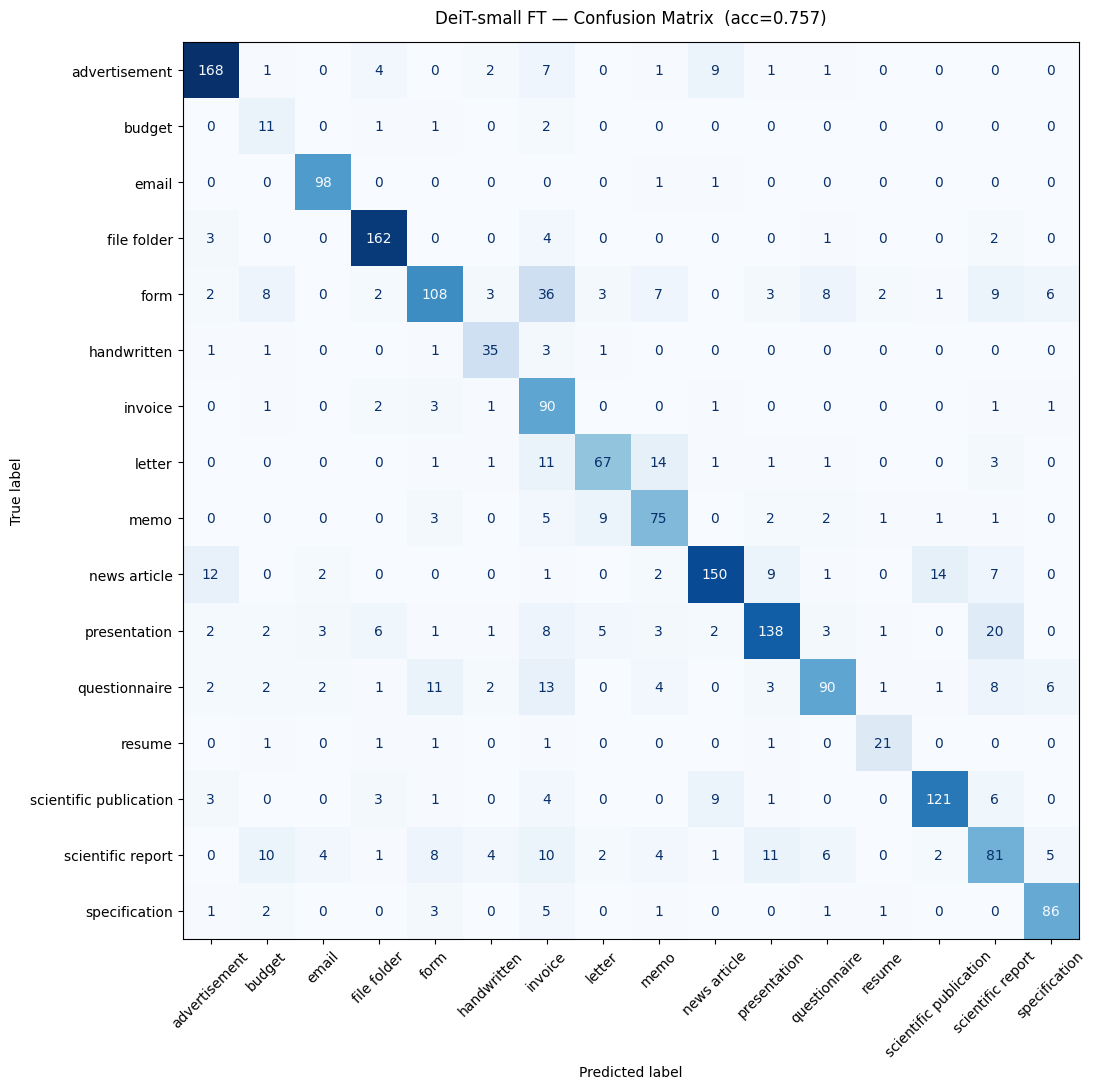

Saved → /content/drive/MyDrive/NLP_Invoices/outputs/03_deit_confusion_matrix.png


In [23]:
# Load the best checkpoint saved during training
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
print(f"✅ Best model caricato da {BEST_MODEL_PATH}")

test_loader  = make_loader(test_examples, processor, augment=False, shuffle=False)
all_preds    = []
all_true     = []

with torch.no_grad():
    for pixel_values, labels in tqdm(test_loader, desc="Test inference"):
        pixel_values = pixel_values.to(DEVICE)
        outputs      = model(pixel_values=pixel_values)
        preds        = outputs.logits.argmax(dim=-1).cpu().tolist()
        all_preds.extend(preds)
        all_true.extend(labels.tolist())

acc      = accuracy_score(all_true, all_preds)
f1_macro = f1_score(all_true, all_preds, average="macro", zero_division=0)
inv_true = [1 if l == INVOICE_LABEL else 0 for l in all_true]
inv_pred = [1 if p == INVOICE_LABEL else 0 for p in all_preds]
inv_f1   = f1_score(inv_true, inv_pred, zero_division=0)

print(f"\n{'─'*55}")
print(f"  DeiT-small (fine-tuned)")
print(f"{'─'*55}")
print(f"  Overall Accuracy : {acc:.3f}")
print(f"  Macro F1         : {f1_macro:.3f}")
print(f"  Invoice F1       : {inv_f1:.3f}\n")
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES,
                             labels=ALL_LABELS, digits=3, zero_division=0))

# Confusion matrix
fig, ax = plt.subplots(figsize=(14, 11))
cm = confusion_matrix(all_true, all_preds, labels=ALL_LABELS)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
ax.set_title(f"DeiT-small FT — Confusion Matrix  (acc={acc:.3f})", fontsize=12, pad=14)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, "03_deit_confusion_matrix.png")
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {path}")

## 10 — Save results

In [25]:
results_path = os.path.join(OUTPUT_DIR, "03_deit_results.txt")
with open(results_path, "w") as f:
    f.write("DeiT-small Fine-Tuning — Results\n")
    f.write("=" * 55 + "\n\n")
    f.write(f"Dataset  : chainyo/rvl-cdip\n")
    f.write(f"Train    : {N_TRAIN_CLASS}/class × {NUM_CLASSES} = {len(train_examples)}\n")
    f.write(f"Val      : {N_VAL_CLASS}/class × {NUM_CLASSES} = {len(val_examples)}\n")
    f.write(f"Test     : {len(test_examples)} esempi totali (split misto)\n")
    f.write(f"Device   : {DEVICE}\n\n")
    f.write(f"Fase 1   : {EPOCHS_HEAD} epoch, LR={LR_HEAD}, solo head\n")
    f.write(f"Fase 2   : {EPOCHS_FULL} epoch, LR={LR_FULL}, top {UNFREEZE_BLOCKS} blocks\n\n")
    f.write(f"Overall Accuracy : {acc:.3f}\n")
    f.write(f"Macro F1         : {f1_macro:.3f}\n")
    f.write(f"Invoice F1       : {inv_f1:.3f}\n\n")
    f.write(classification_report(all_true, all_preds, target_names=CLASS_NAMES,
                                  labels=ALL_LABELS, digits=3, zero_division=0))

print(f"Results saved → {results_path}")
print("\n✅ Step 3 (DeiT-small fine-tuning) complete.")

Results saved → /content/drive/MyDrive/NLP_Invoices/outputs/03_deit_results.txt

✅ Step 3 (DeiT-small fine-tuning) complete.


## 11 — Comparison with few-shot models (Step 2)
Loads the checkpoint from notebook 02 and adds fine-tuned DeiT to the full comparison.

In [26]:
CHECKPOINT_02 = os.path.join(OUTPUT_DIR, "checkpoint_fewshot.pkl")

if os.path.isfile(CHECKPOINT_02):
    with open(CHECKPOINT_02, "rb") as f:
        ckpt = pickle.load(f)
    RESULTS_02    = ckpt["RESULTS"]
    true_labels_02 = ckpt["true_labels"]
    print(f"✅ Checkpoint 02 caricato. Modelli: {list(RESULTS_02.keys())}")
else:
    RESULTS_02    = {}
    true_labels_02 = None
    print("⚠️  Checkpoint 02 non trovato — il confronto mostrerà solo DeiT fine-tuned.")
    print(f"   Percorso atteso: {CHECKPOINT_02}")

✅ Checkpoint 02 caricato. Modelli: ['Qwen2-VL-7B', 'Qwen2.5-VL-3B', 'CLIP ViT-B/32', 'PaliGemma2-3B', 'DiT-large']


In [27]:
# Build unified results dict with all models
# Fine-tuned DeiT uses the current test set true labels
ALL_RESULTS = dict(RESULTS_02)  # copia shallow dei modelli few-shot

ALL_RESULTS["DeiT-small FT"] = {
    "preds"    : all_preds,
    "accuracy" : acc,
    "f1_macro" : f1_macro,
    "inv_f1"   : inv_f1,
    "unparsed" : 0,           # supervised: nessun parse fallito
}

# Se i true_labels del checkpoint 02 e del test corrente hanno lunghezze diverse
# (es. campionamento diverso) avvisa ma procedi comunque con i dati disponibili
if true_labels_02 is not None and len(true_labels_02) != len(all_true):
    print(f"⚠️  Attenzione: test set 02 ({len(true_labels_02)}) ≠ test set 03 ({len(all_true)}).")
    print("   Le metriche dei modelli few-shot sono calcolate sul loro test set originale,")
    print("   DeiT FT è calcolato sul test set di questo notebook.")
    print("   Il confronto è indicativo ma non perfettamente allineato.")

print("Modelli nel confronto:", list(ALL_RESULTS.keys()))

⚠️  Attenzione: test set 02 (1600) ≠ test set 03 (1982).
   Le metriche dei modelli few-shot sono calcolate sul loro test set originale,
   DeiT FT è calcolato sul test set di questo notebook.
   Il confronto è indicativo ma non perfettamente allineato.
Modelli nel confronto: ['Qwen2-VL-7B', 'Qwen2.5-VL-3B', 'CLIP ViT-B/32', 'PaliGemma2-3B', 'DiT-large', 'DeiT-small FT']


## 12 — Comparative bar chart

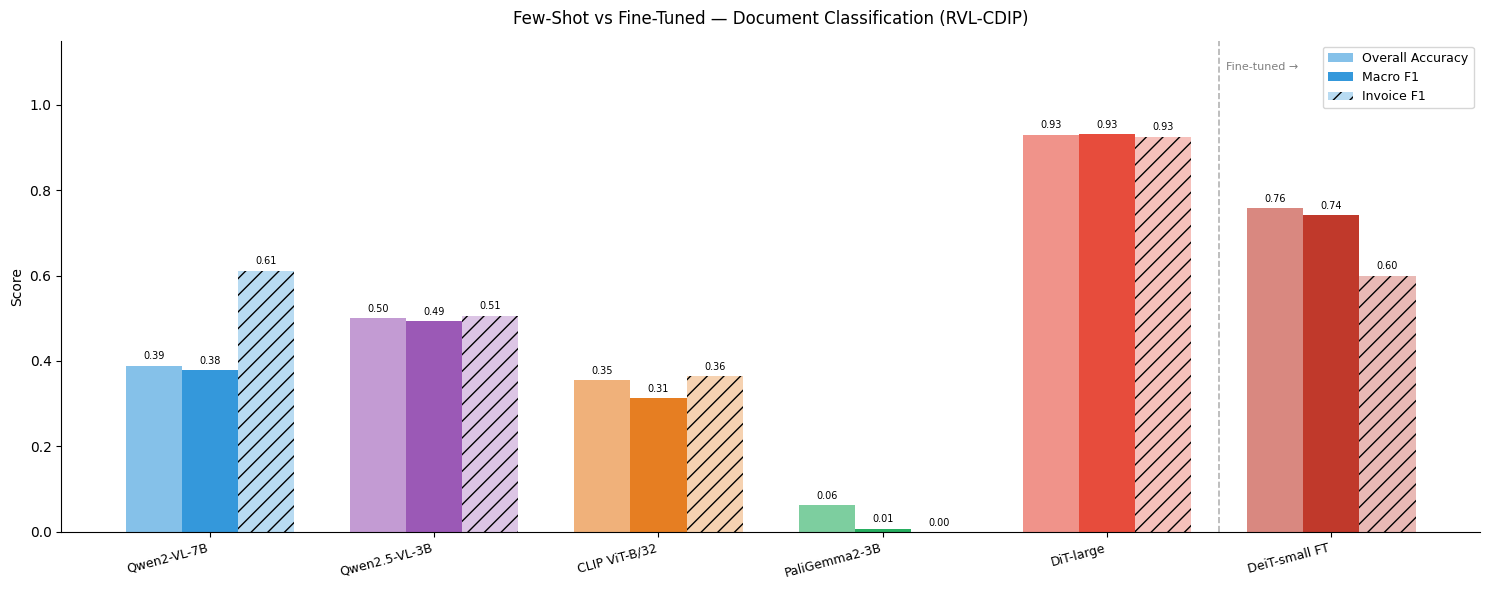

Saved → /content/drive/MyDrive/NLP_Invoices/outputs/03_comparison_fewshot_vs_ft.png


In [28]:
model_names = list(ALL_RESULTS.keys())
accs     = [ALL_RESULTS[m]["accuracy"]  for m in model_names]
f1_macro = [ALL_RESULTS[m]["f1_macro"]  for m in model_names]
inv_f1   = [ALL_RESULTS[m]["inv_f1"]    for m in model_names]

# DeiT FT evidenziato con colore diverso
COLOURS_BASE = ["#3498db", "#9b59b6", "#e67e22", "#27ae60",
                "#e74c3c", "#1abc9c", "#f39c12"]
colours = []
for name in model_names:
    if "DeiT" in name:
        colours.append("#c0392b")   # rosso per DeiT FT — si distingue subito
    else:
        colours.append(COLOURS_BASE[len(colours) % len(COLOURS_BASE)])

x = np.arange(len(model_names))
w = 0.25

fig, ax = plt.subplots(figsize=(max(15, len(model_names)*2.2), 6))
b1 = ax.bar(x - w, accs,     w, label="Overall Accuracy", color=colours, alpha=0.6)
b2 = ax.bar(x,     f1_macro, w, label="Macro F1",         color=colours)
b3 = ax.bar(x + w, inv_f1,   w, label="Invoice F1",       color=colours, alpha=0.35, hatch="//")

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.2f}",
                ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=9, rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.15)
ax.set_title("Few-Shot vs Fine-Tuned — Document Classification (RVL-CDIP)", fontsize=12, pad=12)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# Linea verticale per separare visivamente i modelli few-shot da DeiT FT
n_fewshot = len([m for m in model_names if "DeiT" not in m])
if n_fewshot > 0 and n_fewshot < len(model_names):
    ax.axvline(n_fewshot - 0.5, color="gray", linestyle="--", linewidth=1.2, alpha=0.6)
    ax.text(n_fewshot - 0.5, 1.10, "  Fine-tuned →", fontsize=8, color="gray", va="top")

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, "03_comparison_fewshot_vs_ft.png")
fig.savefig(path, dpi=150)
plt.show()
print(f"Saved → {path}")

## 13 — Summary table

In [29]:
print("\n── Summary table ──────────────────────────────────────────────────")
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10} {'Invoice F1':>12} {'Unparsed':>10} {'Type':>12}")
print("─" * 82)

best_acc = max(accs)
best_inv = max(inv_f1)

for m in model_names:
    r        = ALL_RESULTS[m]
    tag_acc  = "★" if r["accuracy"] == best_acc else " "
    tag_inv  = "★" if r["inv_f1"]   == best_inv else " "
    mtype    = "fine-tuned" if "DeiT" in m else "few-shot"
    print(f"{m:<25} {r['accuracy']:>10.3f}{tag_acc} {r['f1_macro']:>10.3f}  "
          f"{r['inv_f1']:>10.3f}{tag_inv} {r['unparsed']:>9}   {mtype:>10}")

print("  ★ = best in category")
print(f"\n  DeiT-small FT trained on {len(train_examples)} images ({N_TRAIN_CLASS}/class × {NUM_CLASSES} classes)")
print(f"  Few-shot models used 1 image/class (16 total) — no gradient updates")


── Summary table ──────────────────────────────────────────────────
Model                       Accuracy   Macro F1   Invoice F1   Unparsed         Type
──────────────────────────────────────────────────────────────────────────────────
Qwen2-VL-7B                    0.389       0.378       0.612          9     few-shot
Qwen2.5-VL-3B                  0.501       0.493       0.506         16     few-shot
CLIP ViT-B/32                  0.354       0.313       0.365          0     few-shot
PaliGemma2-3B                  0.063       0.007       0.000         15     few-shot
DiT-large                      0.930★      0.930       0.925★         0     few-shot
DeiT-small FT                  0.757       0.741       0.600          0   fine-tuned
  ★ = best in category

  DeiT-small FT trained on 32000 images (2000/class × 16 classes)
  Few-shot models used 1 image/class (16 total) — no gradient updates


## 14 — Save final comparison

In [30]:
comparison_path = os.path.join(OUTPUT_DIR, "03_comparison_results.txt")
with open(comparison_path, "w") as f:
    f.write("Few-Shot vs Fine-Tuned — Document Classification Results\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Dataset : chainyo/rvl-cdip\n")
    f.write(f"Device  : {DEVICE}\n\n")
    f.write(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10} {'Invoice F1':>12} {'Type':>12}\n")
    f.write("─" * 72 + "\n")
    for m in model_names:
        r     = ALL_RESULTS[m]
        mtype = "fine-tuned" if "DeiT" in m else "few-shot"
        f.write(f"{m:<25} {r['accuracy']:>10.3f} {r['f1_macro']:>10.3f}"
                f" {r['inv_f1']:>12.3f}   {mtype:>10}\n")

print(f"Confronto salvato → {comparison_path}")
print("\n✅ Step 3 completo — fine-tuning + confronto few-shot vs fine-tuned.")

Confronto salvato → /content/drive/MyDrive/NLP_Invoices/outputs/03_comparison_results.txt

✅ Step 3 completo — fine-tuning + confronto few-shot vs fine-tuned.
